**Medical Insurance Cost Prediction Using Linear Regression**
**Problem Statement**

Medical insurance providers need reliable methods to estimate the expected healthcare costs of individuals before issuing insurance policies. Factors such as age, body mass index (BMI), smoking habits, number of children, sex, and region can significantly influence insurance expenses. Estimating these costs manually can be inconsistent and time-consuming. Therefore, there is a need for a data-driven solution that accurately predicts medical insurance charges based on an individual's characteristics.


**Use Case**

This project develops a multivariate linear regression model to predict annual medical insurance charges using demographic and lifestyle information. The model can support insurance companies in estimating premiums more accurately while helping customers understand the factors influencing their insurance costs.


**Objectives**

*   Build a linear regression model for predicting insurance charges.
*   Perform data cleaning and preprocessing.
*   Visualize and interpret the dataset.
*   Compare multiple regression algorithms.
*   Save the best-performing model for deployment through FastAPI.






In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("insurance.csv")

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [10]:
df.duplicated().sum()

np.int64(1)

In [11]:
# Removing duplicate rows
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(1337, 7)

**Data Cleaning**

I checked the dataset for missing values and duplicates and no missing values were found in any of the columns. However, I found one duplicate row and removed it to improve data quality and prevent bias during model training. After removing the duplicate, the dataset contained 1337 unique observations and 7 variables, making it suitable for further analysis and model development.

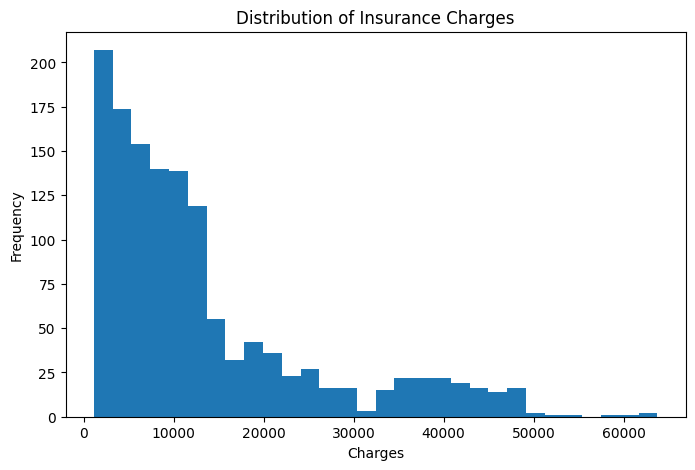

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['charges'], bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

### **Interpretation**

The histogram shows that insurance charges are positively skewed. Most individuals have relatively low insurance costs, while a smaller number of people have significantly higher charges. This indicates that some factors, such as smoking status or BMI, may greatly increase medical insurance expenses.

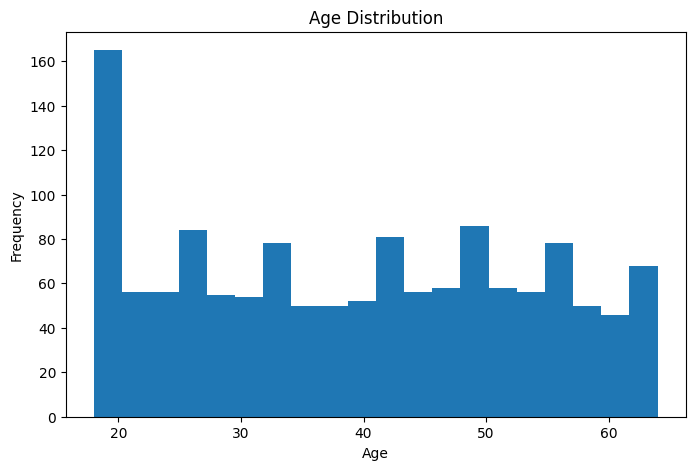

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### **Interpretation**

The age distribution is relatively balanced across the dataset. Individuals from different age groups are represented, allowing the regression model to learn how age influences insurance charges without being biased toward a particular age range.

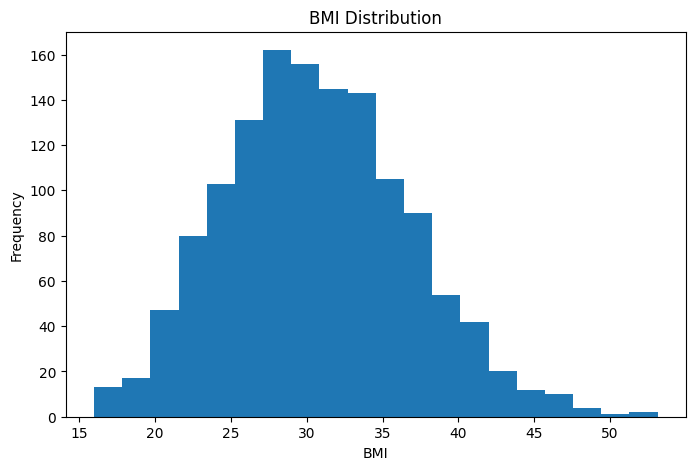

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['bmi'], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

### **Interpretation**

The BMI values are concentrated around the middle range, with fewer individuals having very low or very high BMI values. Since BMI is closely related to health risks, it is expected to have an impact on insurance charges.

In [17]:
import seaborn as sns

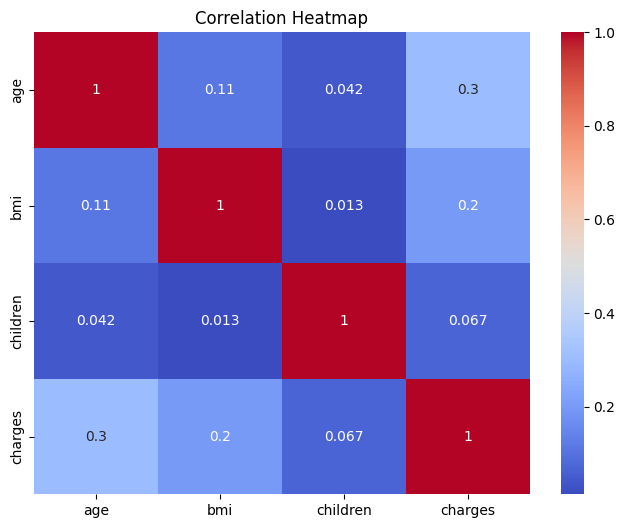

In [18]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### **Interpretation**

The correlation heatmap shows the relationships among numerical variables. Insurance charges have a positive correlation with age and BMI, indicating that increases in these variables are generally associated with higher insurance costs. The heatmap also helps identify whether any numerical features are highly correlated with each other.

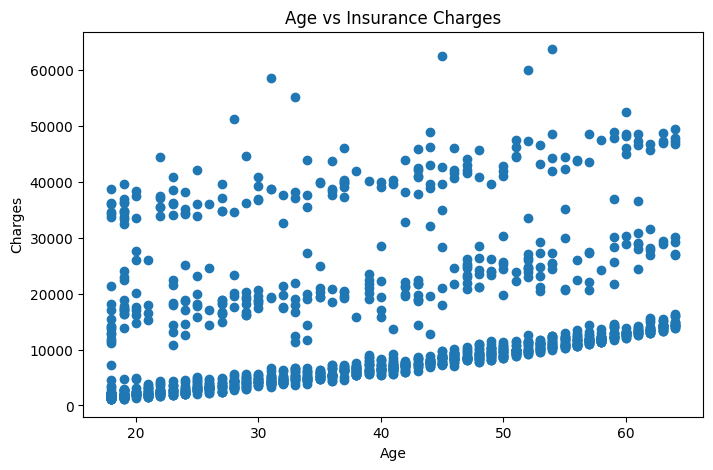

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['charges'])

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

### **Interpretation**

The scatter plot suggests a positive relationship between age and insurance charges. As age increases, insurance charges tend to increase. However, the spread of points indicates that other variables, such as smoking status and BMI, also influence the insurance cost.

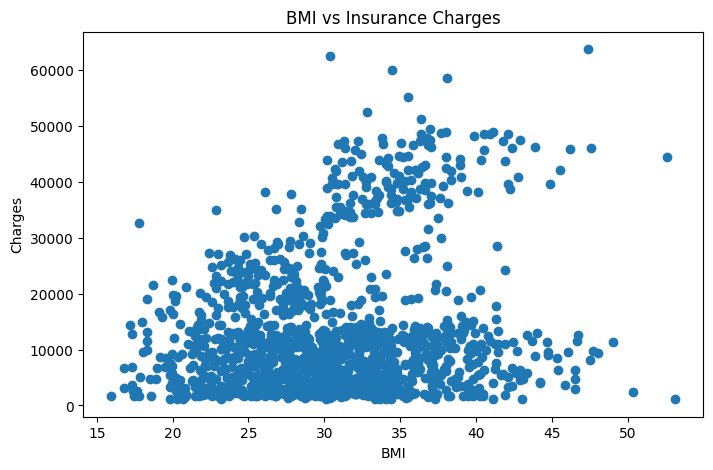

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df['bmi'], df['charges'])

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

### **Interpretation**

The scatter plot shows that individuals with higher BMI values generally tend to have higher insurance charges. However, the relationship is not perfectly linear, suggesting that BMI is one of several factors influencing insurance costs.

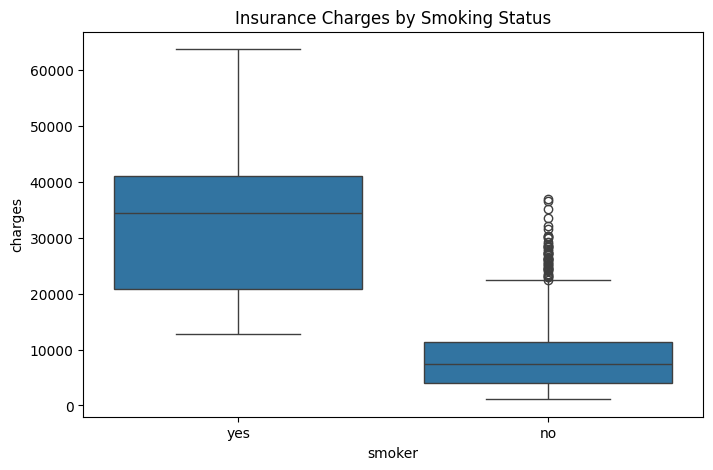

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='smoker', y='charges', data=df)

plt.title("Insurance Charges by Smoking Status")

plt.show()

### **Interpretation**

The box plot shows that smokers have significantly higher insurance charges than non-smokers. This indicates that smoking status is likely one of the most influential predictors of medical insurance costs.

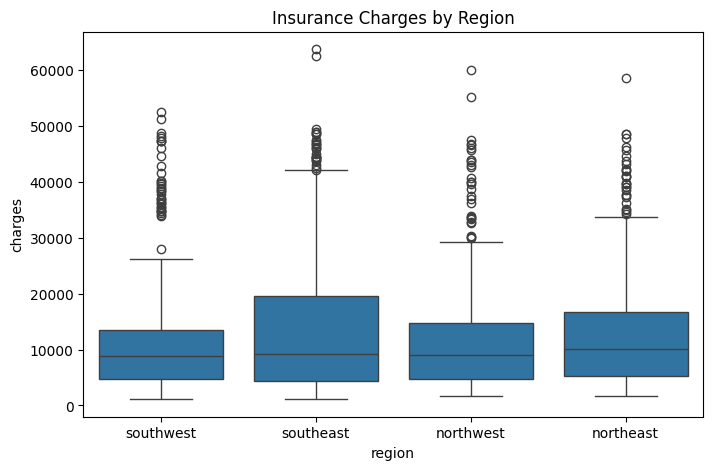

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x='region', y='charges', data=df)

plt.title("Insurance Charges by Region")

plt.show()

### **Interpretation**

Insurance charges vary slightly across regions, although the differences are less pronounced than those observed for smoking status. This suggests that region may have some influence on charges but is not the strongest predictor.

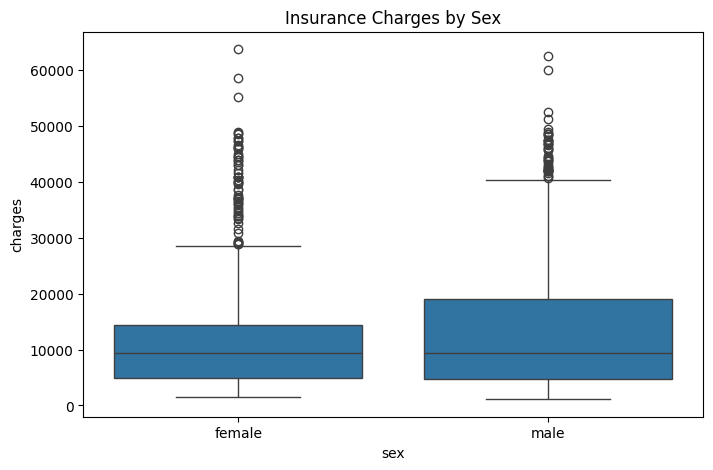

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x='sex', y='charges', data=df)

plt.title("Insurance Charges by Sex")

plt.show()

### **Interpretation**

The distribution of insurance charges is relatively similar between males and females. This suggests that sex alone may not be a strong predictor of insurance charges compared to other variables such as smoking status or BMI.

### **Feature Engineering**

This will involve identifying important features, removing unnecessary ones, converting categorical variables into numerical form, and preparing the dataset for model training. Proper feature engineering improves the performance and accuracy of machine learning models.

In [24]:
# Features (Independent Variables)
X = df.drop('charges', axis=1)

# Target (Dependent Variable)
y = df['charges']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


### **Interpretation**

The dataset contains six independent variables (`age`, `sex`, `bmi`, `children`, `smoker`, and `region`) that are used to predict the dependent variable (`charges`). Since `charges` is the value we want the model to estimate, it is selected as the target variable.

### **Feature Selection**

All six predictor variables are retained because each has a meaningful relationship with insurance charges.

- **Age:** Older individuals generally incur higher healthcare costs.
- **Sex:** May contribute to differences in healthcare utilization.
- **BMI:** Higher BMI is associated with increased health risks and medical expenses.
- **Children:** The number of dependents may influence insurance coverage and costs.
- **Smoker:** Smoking significantly increases health risks and insurance charges.
- **Region:** Healthcare costs may vary across different geographical regions.

I will remove no column because none were identified as irrelevant or redundant for this prediction task.

In [25]:
X.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object


### Categorical Variables

The variables `sex`, `smoker`, and `region` are categorical and cannot be processed directly by most machine learning algorithms. These variables must therefore be converted into numerical representations before model training.

In [26]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


### Encoding Categorical Variables

One-hot encoding was used to convert the categorical variables into numerical format. This method creates binary (0 or 1) columns representing each category while avoiding an artificial ordering of categories. The `drop_first=True` option was used to prevent multicollinearity by removing one category from each feature.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.44041773 -0.45315959 -0.90923416 ... -0.5655458  -0.61163774
   1.76460935]
 [-1.51164747  0.50942165 -0.07944162 ... -0.5655458   1.63495472
  -0.56669767]
 [-0.79935006  0.3831546   1.58014347 ... -0.5655458   1.63495472
  -0.56669767]
 ...
 [-1.51164747  1.01448983 -0.90923416 ... -0.5655458   1.63495472
  -0.56669767]
 [-1.29795825 -0.79752426 -0.90923416 ... -0.5655458  -0.61163774
   1.76460935]
 [ 1.55123139 -0.26129928 -0.90923416 ...  1.76820338 -0.61163774
  -0.56669767]]


### **Standardization**

The numerical features were standardized using `StandardScaler`, which transforms the data so that each feature has a mean of approximately 0 and a standard deviation of 1. Standardization prevents variables with larger scales from dominating the learning process and improves the performance of gradient-based algorithms such as Stochastic Gradient Descent (SGD).

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1069
Testing samples: 268


### **Train-Test Split**

The dataset was divided into training and testing sets using an 80:20 ratio. The training data is used to build the regression models, while the testing data is used to evaluate how well the models perform on unseen data.

# **Model Training**

In this section, the models will be compared using standard regression evaluation metrics, and the best-performing model will be selected for deployment.

In [29]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [30]:
# Predict on the test data
linear_predictions = linear_model.predict(X_test)

print(linear_predictions[:10])

[ 8143.69388412  5737.11568259 14369.31487618 31745.51363586
  8962.38665706 13149.72235307 30446.76067941  1453.28881259
 10633.01840233 11318.94379361]


In [31]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [32]:
#Calculating the metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R² :", linear_r2)

Linear Regression Results
-------------------------
MAE : 4177.045561036324
MSE : 35478020.67523559
RMSE: 5956.342894363587
R² : 0.8069287081198012


### **Linear Regression Performance**

The Linear Regression model was trained using the standardized training dataset and evaluated on the testing dataset. The model's performance was assessed using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² score.

Lower values of MAE, MSE, and RMSE indicate better prediction accuracy, while an R² score closer to 1 indicates that the model explains a larger proportion of the variation in insurance charges.

In [33]:
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(
    random_state=42,
    max_iter=1000,
    learning_rate='invscaling',
    eta0=0.01
)

sgd_model.fit(X_train, y_train)

print("SGD Regressor trained successfully.")

SGD Regressor trained successfully.


In [35]:
sgd_predictions = sgd_model.predict(X_test)

In [36]:
sgd_mae = mean_absolute_error(y_test, sgd_predictions)
sgd_mse = mean_squared_error(y_test, sgd_predictions)
sgd_rmse = np.sqrt(sgd_mse)
sgd_r2 = r2_score(y_test, sgd_predictions)

print("SGD Regression Results")
print("----------------------")
print("MAE :", sgd_mae)
print("MSE :", sgd_mse)
print("RMSE:", sgd_rmse)
print("R² :", sgd_r2)

SGD Regression Results
----------------------
MAE : 4169.336799343805
MSE : 35589310.23803483
RMSE: 5965.677684725753
R² : 0.8063230706221765


In [37]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

In [38]:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results")
print("------------------------")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² :", ridge_r2)

Ridge Regression Results
------------------------
MAE : 4179.664232750219
MSE : 35513023.46924248
RMSE: 5959.280448950401
R² : 0.8067382230101557


In [40]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [41]:
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree Results")
print("---------------------")
print("MAE :", tree_mae)
print("MSE :", tree_mse)
print("RMSE:", tree_rmse)
print("R² :", tree_r2)

Decision Tree Results
---------------------
MAE : 2777.8549919738807
MSE : 34226992.05307391
RMSE: 5850.3839235621035
R² : 0.8137368024740745


In [42]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    random_state=42,
    n_estimators=100
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

In [43]:
forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_mse = mean_squared_error(y_test, forest_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, forest_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", forest_mae)
print("MSE :", forest_mse)
print("RMSE:", forest_rmse)
print("R² :", forest_r2)

Random Forest Results
---------------------
MAE : 2652.5794811223873
MSE : 22221459.84061429
RMSE: 4713.964344436038
R² : 0.879070876073814


In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SGD Regressor",
        "Ridge Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        sgd_mae,
        ridge_mae,
        tree_mae,
        forest_mae
    ],
    "MSE": [
        linear_mse,
        sgd_mse,
        ridge_mse,
        tree_mse,
        forest_mse
    ],
    "RMSE": [
        linear_rmse,
        sgd_rmse,
        ridge_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R2 Score": [
        linear_r2,
        sgd_r2,
        ridge_r2,
        tree_r2,
        forest_r2
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4177.045561,3.547802e+07,5956.342894,0.806929
1,SGD Regressor,4169.336799,3.558931e+07,5965.677685,0.806323
2,Ridge Regression,4179.664233,3.551302e+07,5959.280449,0.806738
3,Decision Tree,2777.854992,3.422699e+07,5850.383924,0.813737
4,Random Forest,2652.579481,2.222146e+07,4713.964344,0.879071


## **Model Comparison**

Five regression algorithms were trained and evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² Score.

For MAE, MSE, and RMSE, lower values indicate better predictive performance. For the R² Score, values closer to 1 indicate that the model explains more of the variability in the target variable.

## **Best Model Selection**

Based on the evaluation metrics, the Random Forest Regressor achieved the best overall performance. It produced the lowest prediction errors (MAE, MSE, and RMSE) and the highest R² Score of approximately 0.879.

This indicates that the Random Forest model explains about 87.9% of the variation in medical insurance charges and predicts unseen data more accurately than the other regression models evaluated. Therefore, it was selected as the final model for deployment.

In [46]:
import joblib

joblib.dump(forest_model, "best_insurance_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


In [47]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [48]:
# Example input
sample = pd.DataFrame({
    'age': [30],
    'bmi': [28.5],
    'children': [2],
    'sex_male': [1],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

# Scale the sample
sample_scaled = scaler.transform(sample)

# Make prediction
prediction = forest_model.predict(sample_scaled)

print("Predicted Insurance Charge: $", round(prediction[0], 2))

Predicted Insurance Charge: $ 4808.61


In [49]:
X.columns

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [50]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# Creating a new SGD model
sgd_loss_model = SGDRegressor(
    random_state=42,
    max_iter=1,
    tol=None,
    learning_rate='invscaling',
    eta0=0.01
)

train_losses = []
test_losses = []

epochs = 100

for epoch in range(epochs):
    sgd_loss_model.partial_fit(X_train, y_train)

    train_pred = sgd_loss_model.predict(X_train)
    test_pred = sgd_loss_model.predict(X_test)

    train_loss = mean_squared_error(y_train, train_pred)
    test_loss = mean_squared_error(y_test, test_pred)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

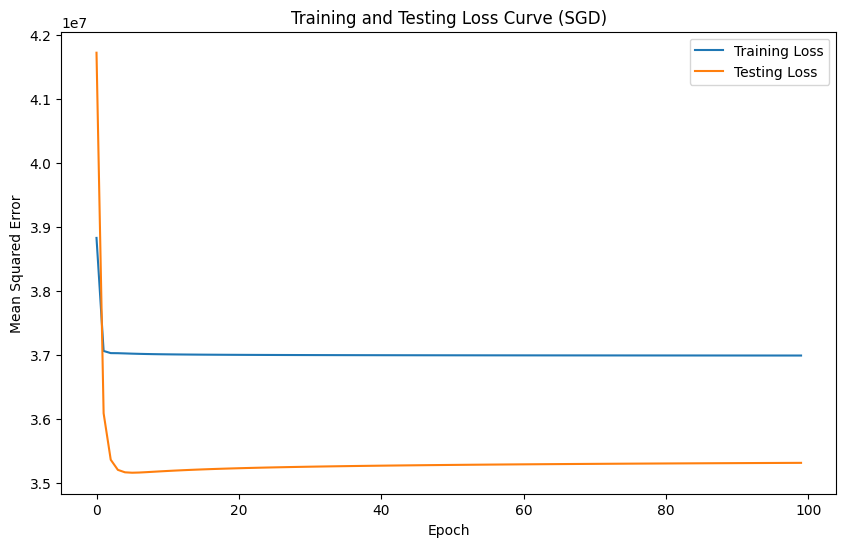

In [51]:
plt.figure(figsize=(10,6))

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")

plt.title("Training and Testing Loss Curve (SGD)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.legend()

plt.show()

### **Loss Curve Interpretation**

The loss curve illustrates how the prediction error changes as the SGD model learns over multiple training epochs. Both the training loss and testing loss decrease rapidly during the initial epochs before stabilizing, indicating that the model is learning effectively. The small gap between the training and testing curves suggests that the model generalizes reasonably well without significant overfitting.

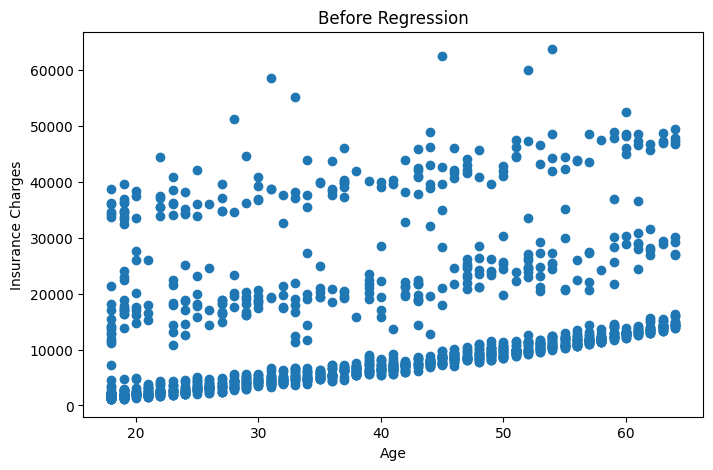

In [52]:
plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['charges'])

plt.title("Before Regression")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

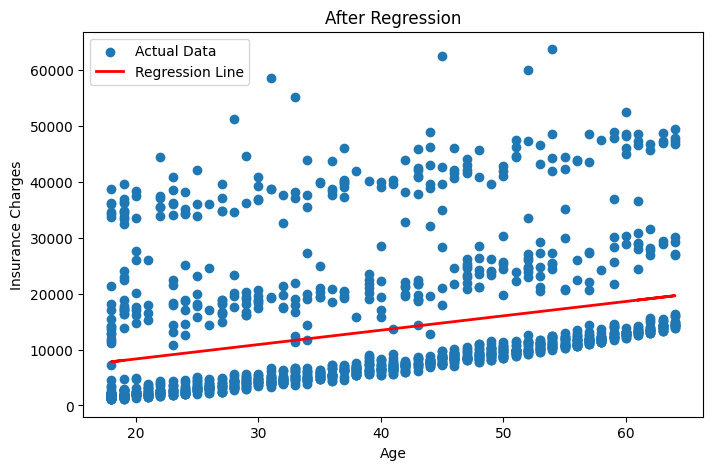

In [53]:
from sklearn.linear_model import LinearRegression

X_age = df[['age']]
y_age = df['charges']

simple_model = LinearRegression()
simple_model.fit(X_age, y_age)

predicted_line = simple_model.predict(X_age)

plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['charges'], label="Actual Data")
plt.plot(df['age'], predicted_line, color='red', linewidth=2, label="Regression Line")

plt.title("After Regression")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.legend()

plt.show()

### **Scatter Plot Interpretation**

The first scatter plot shows the raw relationship between age and insurance charges. The second plot overlays the regression line, illustrating the overall trend learned by the linear regression model. Although individual data points vary due to the influence of additional variables such as BMI and smoking status, the regression line captures the general increase in insurance charges as age increases.

In [54]:
import joblib

# Load the saved model and scaler
loaded_model = joblib.load("best_insurance_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Create sample input
sample = pd.DataFrame({
    'age': [30],
    'bmi': [28.5],
    'children': [2],
    'sex_male': [1],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

# Scale the input
sample_scaled = loaded_scaler.transform(sample)

# Predict
prediction = loaded_model.predict(sample_scaled)

print(f"Predicted Insurance Charge: ${prediction[0]:.2f}")

Predicted Insurance Charge: $4808.61


# **Hyperparameter Optimization of SGD Regressor**

Hyperparameter tuning was performed on the Stochastic Gradient Descent (SGD) Regressor to identify the combination of parameters that produces the best predictive performance. Different values of the regularization parameter (`alpha`), learning rate (`eta0`), and maximum number of iterations (`max_iter`) were tested and compared using the R² Score.

In [55]:
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score

# Hyperparameter combinations
param_grid = {
    'alpha': [0.0001, 0.001, 0.01],
    'eta0': [0.001, 0.01, 0.1],
    'max_iter': [1000, 2000]
}

results = []

for params in ParameterGrid(param_grid):

    model = SGDRegressor(
        random_state=42,
        learning_rate='constant',
        alpha=params['alpha'],
        eta0=params['eta0'],
        max_iter=params['max_iter']
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)

    results.append({
        "Alpha": params['alpha'],
        "Eta0": params['eta0'],
        "Max Iter": params['max_iter'],
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="R2 Score", ascending=False)

,Alpha,Eta0,Max Iter,R2 Score
0,0.0001,0.001,1000,0.806260
1,0.0001,0.001,2000,0.806260
7,0.0010,0.001,2000,0.806077
6,0.0010,0.001,1000,0.806077
12,0.0100,0.001,1000,0.804209
13,0.0100,0.001,2000,0.804209
14,0.0100,0.010,1000,0.803346
15,0.0100,0.010,2000,0.803346
2,0.0001,0.010,1000,0.754997
3,0.0001,0.010,2000,0.754997


In [56]:
best_result = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]

best_result

,0
Alpha,0.00010
Eta0,0.00100
Max Iter,1000.00000
R2 Score,0.80626


In [57]:
optimized_sgd = SGDRegressor(
    random_state=42,
    learning_rate='constant',
    alpha=0.0001,
    eta0=0.001,
    max_iter=1000
)

optimized_sgd.fit(X_train, y_train)

optimized_predictions = optimized_sgd.predict(X_test)

In [58]:
optimized_mae = mean_absolute_error(y_test, optimized_predictions)
optimized_mse = mean_squared_error(y_test, optimized_predictions)
optimized_rmse = np.sqrt(optimized_mse)
optimized_r2 = r2_score(y_test, optimized_predictions)

print("Optimized SGD Results")
print("---------------------")
print("MAE :", optimized_mae)
print("MSE :", optimized_mse)
print("RMSE:", optimized_rmse)
print("R² :", optimized_r2)

Optimized SGD Results
---------------------
MAE : 4169.169545492962
MSE : 35600892.13872992
RMSE: 5966.648316997569
R² : 0.8062600419501403


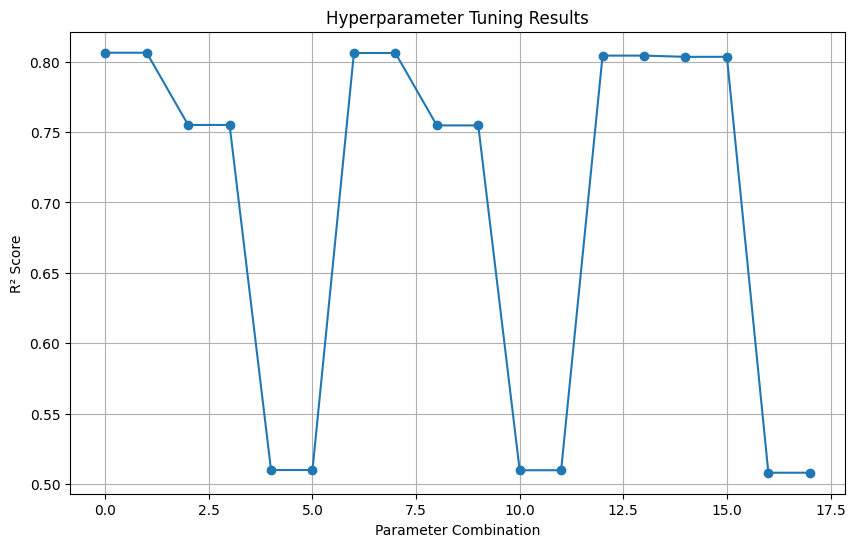

In [59]:
plt.figure(figsize=(10,6))

plt.plot(results_df["R2 Score"], marker='o')

plt.title("Hyperparameter Tuning Results")
plt.xlabel("Parameter Combination")
plt.ylabel("R² Score")

plt.grid(True)

plt.show()

### **Interpretation**

The graph illustrates the R² scores obtained from different combinations of SGD hyperparameters. While several parameter combinations produced similar performance, the best configuration achieved an R² score of approximately 0.8063. This demonstrates that hyperparameter tuning can influence model performance, although the improvement depends on the characteristics of the dataset.

# **Conclusion**

This project successfully developed and evaluated multiple regression models for predicting medical insurance charges. The dataset was cleaned, explored through visualizations, and preprocessed using feature engineering techniques such as categorical encoding and feature standardization.

Five regression models were trained and evaluated: Linear Regression, SGD Regressor, Ridge Regression, Decision Tree Regressor, and Random Forest Regressor. Among these, the Random Forest Regressor achieved the best predictive performance, obtaining the highest R² Score (0.879) and the lowest prediction errors.

The trained Random Forest model was saved and will be deployed through a FastAPI application in the other following Tasks.